In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Normalization
import matplotlib.pyplot as plt

from adaptive_latents import datasets
import numpy as np
from adaptive_latents.utils import resample_matched_timeseries


In [26]:
d = datasets.Odoherty21Dataset(bin_width=0.03)  # (timesteps x neurons)

In [27]:
from adaptive_latents import StreamingKalmanFilter
from adaptive_latents.sim_stim import make_sr
from itertools import cycle

kwargs = dict(
        autoreg=StreamingKalmanFilter,
        isi_generator=cycle([3]),
        stim_rate=None,
        exit_time=np.inf,
        decay_rate=.8,
        prosvd_k=10,
        max_l0_norm=30,
        attempt_correction=True,
        heed_stimuli=True,
        stim_time_delay=0,
        regressor_stim_delay=0,
        optimization_method='cheat_lowd_vec',
        u_to_s_model_type='identity',
        design_type=None,
        true_S='identity',
        stim_timing_method='isi',
        n_identity_prior=10,
        stim_direction_type='first',
        initial_nostim_period=5,
        stim_reg_maxlen=500,
        smoothing_tau=None,
        centerer_init_size=0,
        last_dim_red='prosvd',
        show_tqdm=True,
)

_, _, log_nostim = make_sr(
        d.neural_data,
        np.random.default_rng(0),
        stim_magnitude=0,
        **kwargs
)

_, _, log_stim = make_sr(
        d.neural_data,
        np.random.default_rng(0),
        stim_magnitude=1000,
        **kwargs
)



preturbed_neural_data = log_nostim['high_d_with_stim']
unpreturbed_neural_data = log_stim['high_d_with_stim']

beh = resample_matched_timeseries(d.behavioral_data, d.behavioral_data.t, unpreturbed_neural_data.t)  # (timesteps x 2)

normalized_beh = (beh - np.nanmean(beh, axis=0)) / np.nanstd(beh, axis=0)

stims = log_stim['stims']
stims.t -= 1e-10

  0%|          | 0/649.0799999999999 [00:00<?, ?it/s]

/home/jgould/Documents/AdaptiveLatents/adaptive_latents/predictor.py:133: UserWarning: there should probably be an autonomous dynamics call here
  warnings.warn('there should probably be an autonomous dynamics call here')
/home/jgould/Documents/AdaptiveLatents/adaptive_latents/sim_stim.py:311: UserWarning: No stims delivered in sim-stim.
  warnings.warn("No stims delivered in sim-stim.")


  0%|          | 0/649.0799999999999 [00:00<?, ?it/s]

In [ ]:
import keras
keras.utils.set_random_seed(812)

n = Normalization()
n.adapt(beh[None,:,:])

model = Sequential(
    [
        Input(shape=unpreturbed_neural_data.shape),
        LSTM(200, return_sequences=True),
        Dense(2),
    ]
)

model.compile(optimizer='adam', loss='mse')
model.fit(unpreturbed_neural_data[None, :,:], normalized_beh[None,:,:], epochs=100, verbose=True)

Epoch 1/100


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 763ms/step - loss: 1.3339
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - loss: 1.0865
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - loss: 1.0688
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - loss: 0.9860
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - loss: 0.9494
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - loss: 0.9231
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - loss: 0.9028
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - loss: 0.8635
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - loss: 0.8169
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - loss: 0.7680
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - loss: 0.7226
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - loss: 0.6773
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - loss: 0.7067
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - loss: 0.9361
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - loss: 0.6481
Epoch 16/100
1/1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


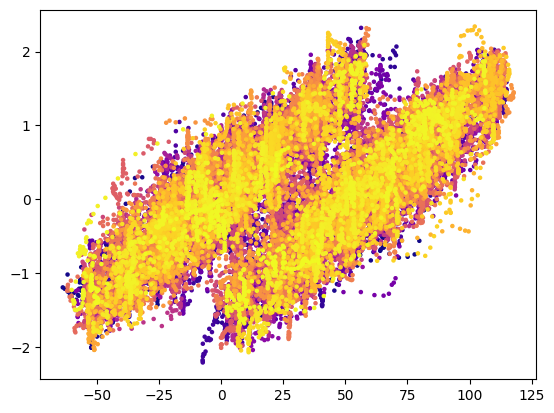

In [29]:
%matplotlib inline

pred = model.predict(unpreturbed_neural_data[None,:,:]).squeeze()
plt.scatter(beh.flatten(), pred.flatten(), s=5, c=np.arange(pred.size), cmap='plasma')


In [30]:
unpreturbed_pred = model.predict(unpreturbed_neural_data[None,:,:]).squeeze()*beh.std(axis=0) + beh.mean(axis=0)
preturbed_pred = model.predict(preturbed_neural_data[None,:,:]).squeeze()*beh.std(axis=0) + beh.mean(axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


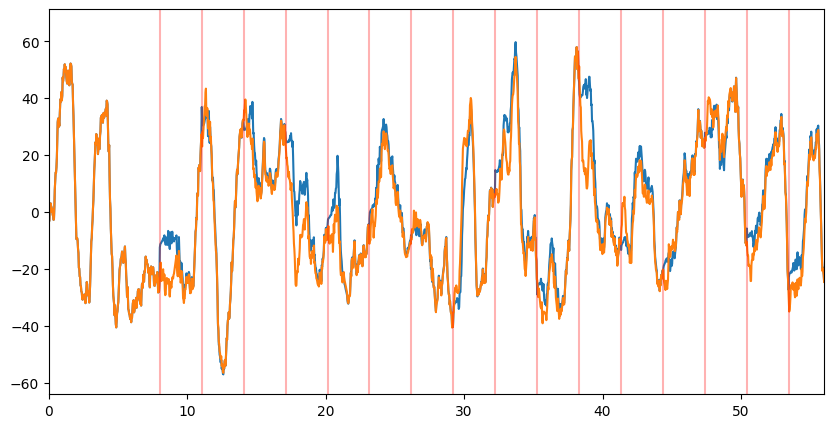

In [31]:
fig, ax = plt.subplots(figsize=(10,5))
# plt.plot(beh.t, beh[:,0])
plt.plot(beh.t, unpreturbed_pred[:,0])
plt.plot(beh.t, preturbed_pred[:,0])

plt.xlim([00, 56])

for t in log_stim['stim_intended_samples'].t:
    plt.axvline(t, color='red', alpha=0.3)


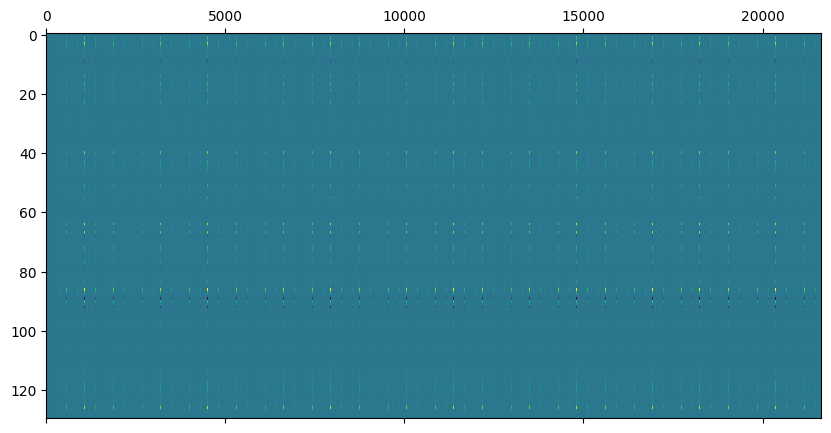

In [32]:
fig, ax = plt.subplots(figsize=(10,5))
ax.matshow(log_stim['high_d_with_stim'].T, aspect='auto')
# log_stim.keys()

In [33]:
from adaptive_latents import StimRegressor
sr_aware = StimRegressor(log_level=2)
sr_unaware = StimRegressor(log_level=2, heed_stimuli=False, attempt_correction=False)


sr_aware.offline_run_on([(preturbed_pred, 'X'), (stims, 'stim')], show_tqdm=True)
sr_unaware.offline_run_on([(preturbed_pred, 'X'), (stims, 'stim')], show_tqdm=True)

  0%|          | 0/647.34 [00:00<?, ?it/s]

/home/jgould/Documents/AdaptiveLatents/adaptive_latents/regressions.py:262: UserWarning: history is full, overwriting old observations
  warnings.warn("history is full, overwriting old observations")
/home/jgould/Documents/AdaptiveLatents/adaptive_latents/transformer.py:214: UserWarning: No outputs were routed to stream '0'.
  warnings.warn(f"No outputs were routed to stream '{convinient_return}'.")


  0%|          | 0/647.34 [00:00<?, ?it/s]

ArrayWithTime([], shape=(0, 1), dtype=float64)

3.4666648932502686
3.467865508698288


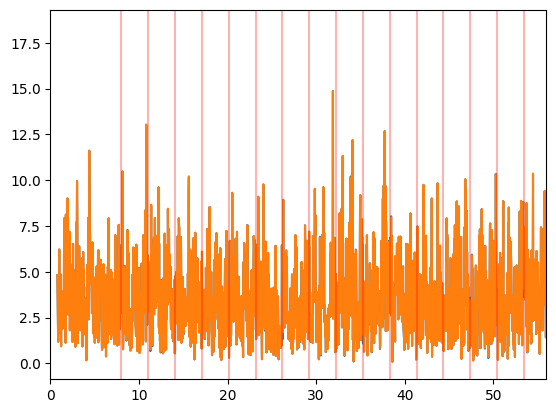

In [34]:
fig, ax = plt.subplots()
from adaptive_latents import ArrayWithTime

e = ArrayWithTime.from_list(sr_unaware.log['pred_error'], squeeze_type='to_2d')
ax.plot(e.t,np.linalg.norm(e, axis=1))
print(np.nanmean(np.linalg.norm(e, axis=1)))

e = ArrayWithTime.from_list(sr_aware.log['pred_error'], squeeze_type='to_2d')
ax.plot(e.t,np.linalg.norm(e, axis=1))
print(np.nanmean(np.linalg.norm(e, axis=1)))

plt.xlim([00, 56])

for t in log_stim['stim_intended_samples'].t:
    plt.axvline(t, color='red', alpha=0.3)
# sr.log.keys()